In [27]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

In [28]:
read_one_case = False

In [71]:
# # First tries:
# # ifile = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/first_try/inference/lam-48h.nc'
# ifile = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/first_try/inference/lam-240h.nc'
# odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/first_try/inference/figures/'
# comparewith = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/1980/ocean_his.nc'

In [30]:
if read_one_case:
    # Xaver case:
    step = '073000'
    ifile = f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step{step}.nc'
    odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case'
    prefix = f'step{step}_'
else:
    odir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/'
    # prefix = 'allruns2013_step112k_'
    prefix = 'allruns2013_step75k_'
comparewith = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2013/ocean_his.nc'

In [3]:
# Create odir if it does not exist
import os
if not os.path.exists(odir):
    os.makedirs(odir)

In [6]:
if read_one_case:
    nc = xr.open_dataset(ifile)
    zeta = nc.zeta
    lat = nc.latitude
    lon = nc.longitude
    time = nc.time
    # x_wind_10m = nc.x_wind_10m
    #
    zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
    lat2 = np.reshape(lat.values, (570, 1014))
    lon2 = np.reshape(lon.values, (570, 1014))
    # x_wind_10m2 = np.reshape(x_wind_10m.values, (x_wind_10m.shape[0], 570, 1014))

In [31]:
nc_c = xr.open_dataset(comparewith)
zeta_c = nc_c.zeta[:,5:575,5:1019]  # cut away the outermost grid cells to match the lam grid
lat_c = nc_c.lat_rho[5:575,5:1019]
lon_c = nc_c.lon_rho[5:575,5:1019]
time_c = nc_c.ocean_time
mask_c = nc_c.mask_rho[5:575,5:1019]
timee_c = np.array([np.datetime64(t) for t in time_c.values])


In [8]:
if read_one_case:
    # Find index of time in time_c
    timee = np.array([np.datetime64(t) for t in time.values])
    timee_c = np.array([np.datetime64(t) for t in time_c.values])
    time_indices = np.where((timee_c >= timee[0]) & (timee_c <= timee[-1]))[0]

In [9]:
if read_one_case:
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning) # Suppress UserWarnings
    # Plot the same as above, but with two subplots, one for the inference and one for the comparison
    minval = -2
    maxval = 2
    colormap = 'RdBu_r'
    # for i in range(0, len(time), 2):
    for i in range(0, 180, 3):
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
        # sc1 = ax1.scatter(lon[:], lat[:], c=zeta[i, :], cmap=colormap, s=0.1, vmin=minval, vmax=maxval)
        # ax1.set_title(f'Inference\nTime index: {i}, Time value: {time[i]}')
        # fig.colorbar(sc1, ax=ax1, label='zeta[m]')
        # sc2 = ax2.scatter(lon_c[:], lat_c[:], c=zeta_c[time_indices[i], :, :].values.flatten(), cmap=colormap, s=0.1, vmin=minval, vmax=maxval)
        # ax2.set_title(f'Comparison\nTime index: {time_indices[i]}, Time value: {timee_c[time_indices[i]]}')
        # fig.colorbar(sc2, ax=ax2, label='zeta[m]')
        pcm1 = ax1.pcolormesh(lon2, lat2, zeta2[i,:,:], cmap=colormap, vmin=minval, vmax=maxval)
        ax1.set_title(f'Inference\nTime index: {i}')
        fig.colorbar(pcm1, ax=ax1, label='zeta[m]')
        pcm2 = ax2.pcolormesh(lon_c, lat_c, zeta_c[time_indices[i], :, :]*mask_c, cmap=colormap, vmin=minval, vmax=maxval)
        ax2.set_title(f'Comparison\nTime index: {time_indices[i]}, Time value: {timee_c[time_indices[i]]}')
        fig.colorbar(pcm2, ax=ax2, label='zeta[m]')
        pcm3 = ax3.pcolormesh(lon_c, lat_c, zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c, cmap='bwr', vmin=-1, vmax=1)
        ax3.set_title(f'Difference\nTime index: {i}')
        fig.colorbar(pcm3, ax=ax3, label='zeta[m]')
        plt.tight_layout()
        plt.savefig(os.path.join(odir, f'{prefix}zeta_compare_{i:03d}.png'), dpi=100)
        # plt.show()
        plt.close()
        print(f'Plotted index {i}, number of plots left: {len(time)-i-1}')

In [10]:
if read_one_case:
    # Using "convert" in os.system to create a gif from the png files
    os.system(f'convert -delay 10 -loop 0 {odir}/{prefix}zeta_compare*.png {odir}/{prefix}zeta_xaver.gif')
    print(f'{odir}/{prefix}zeta_xaver.gif created successfully.')

In [79]:
# LIst all the gif files in odir
gif_files = [f for f in os.listdir(odir) if f.endswith('.gif')]
print('GIF files in output directory:')
for gif in gif_files:
    print(os.path.join(odir, gif))

GIF files in output directory:
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case/step021924_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case/step049000_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case/step073000_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case/step010962_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case/step060000_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case/step030000_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case/step043848_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/xaver_case/step032886_zeta_xav

TODO: Plot timseries for all runs, start with Cuxhaven

In [ ]:
if read_one_case:
    # Cuxhaven coordinates
    sta_lat = 53.87
    sta_lon = 8.72
    staname = 'Cuxhaven'
    # Oscarsborg coordinates 66 NO_OSC 59.678074 10.604861
    # sta_lat = 59.68
    # sta_lon = 10.60
    # staname = 'Oscarsborg'
    # Bergen coordinates 53 NO_BGO 60.398045 5.320487
    # sta_lat = 60.40
    # sta_lon = 5.32
    # staname = 'Bergen'
    # Do the same for the comparison data
    lat_c_arr = np.array(lat_c[:])
    lon_c_arr = np.array(lon_c[:])
    dist_c = np.sqrt((lat_c_arr - sta_lat)**2 + (lon_c_arr - sta_lon)**2)
    min_index_c = np.unravel_index(np.argmin(dist_c), dist_c.shape)
    print(f'Nearest point to {staname} in comparison data: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
    # If land point, find new position:
    if mask_c[min_index_c] == 0:
        print('Nearest point is on land, searching for nearest sea point...')
        sea_indices = np.where(mask_c == 1)
        sea_lats = lat_c_arr[sea_indices]
        sea_lons = lon_c_arr[sea_indices]
        dist_sea = np.sqrt((sea_lats - sta_lat)**2 + (sea_lons - sta_lon)**2)
        min_sea_index = np.argmin(dist_sea)
        min_index_c = (sea_indices[0][min_sea_index], sea_indices[1][min_sea_index])
        print(f'New nearest sea point: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
        # Update sta_lat and sta_lon
        sta_lat = lat_c_arr[min_index_c]
        sta_lon = lon_c_arr[min_index_c]
    # Find the nearest point in the lat/lon grid
    import numpy as np
    lat_arr = np.array(lat[:])
    lon_arr = np.array(lon[:])
    dist = np.sqrt((lat_arr - sta_lat)**2 + (lon_arr - sta_lon)**2)
    min_index = np.unravel_index(np.argmin(dist), dist.shape)
    print(f'Nearest point to {staname}: lat={lat_arr[min_index]}, lon={lon_arr[min_index]} at index {min_index}')

Nearest point to Cuxhaven in comparison data: lat=53.877716064453125, lon=8.72961711883545 at index (1, 259)
Nearest point is on land, searching for nearest sea point...
New nearest sea point: lat=53.926902770996094, lon=8.723377227783203 at index (2, 260)
Nearest point to Cuxhaven: lat=53.926902770996094, lon=8.723377227783203 at index (2288,)


In [81]:
# plt.pcolormesh(mask_c[min_index_c[0]-5:min_index_c[0]+5, min_index_c[1]-5:min_index_c[1]+5], cmap='gray')

In [32]:
import glob
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step*.nc')
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/????-??-??_240h_step112000.nc')
ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/????-??-??_240h_step075000.nc')
ifiles.sort()


In [33]:
for ifile in ifiles:
    print(f'Processing file: {ifile}')

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-01-01_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-01-11_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-01-21_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-01-31_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-02-10_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-02-20_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-03-02_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-03-12_240h_step075000.nc
Processi

In [ ]:
# # Plot the two time series
# fig, ax = plt.subplots(figsize=(10, 5))
# for file in ifiles:
#     nc = xr.open_dataset(file)
#     zeta = nc.zeta
#     time = nc.time
#     # Calculate RMSE for this time series compared to the comparison data
#     zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]].values
#     zeta_series = zeta[:, min_index[0]].values
#     rmse = np.sqrt(np.mean((zeta_series - zeta_c_series)**2))
#     print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
#     ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, ({rmse:.2f}m)', lw=1, alpha=0.7)
# # Plot the comparison data time series
# ax.plot(time_c[time_indices], zeta_c[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge (comparison)', lw=2, color='k')
# ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
# ax.set_xlabel('Time')
# ax.set_ylabel('zeta [m]')
# ax.legend(fontsize='small')
# plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
# plt.show()

In [ ]:
# # Plot the two time series
# for file in ifiles:
#     fig, ax = plt.subplots(figsize=(10, 5))
#     nc = xr.open_dataset(file)
#     zeta = nc.zeta
#     time = nc.time
#     # Calculate RMSE for this time series compared to the comparison data
#     zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]].values
#     zeta_series = zeta[:, min_index[0]].values
#     rmse = np.sqrt(np.mean((zeta_series - zeta_c_series)**2))
#     print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
#     ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, ({rmse:.2f}m)', lw=1, alpha=0.7)
#     # Plot the comparison data time series
#     ax.plot(time_c[time_indices], zeta_c[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge (comparison)', lw=2, color='k')
#     ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
#     ax.set_xlabel('Time')
#     ax.set_ylabel('zeta [m]')
#     ax.legend(fontsize='small')
#     # plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
#     plt.show()

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step010962.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step021924.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step023000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step030000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step032886.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step043848.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/xaver_2013-12-01_240h_step049000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/infere

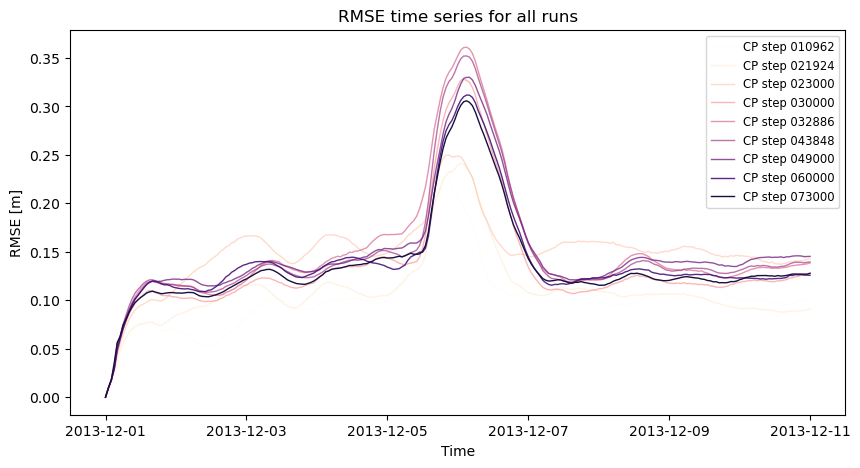

In [ ]:
# # Calulate RMSE between inference and NORA surge for all time steps for all runs, and plot as time series
# rmse = np.zeros((len(ifiles), len(time)))
# for ifile_idx, ifile in enumerate(ifiles):
#     print(f'Processing file: {ifile}')
#     nc = xr.open_dataset(ifile)
#     zeta = nc.zeta
#     zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
#     for i in range(len(time)):
#         rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))


In [ ]:
# # Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
# import matplotlib.cm as cm
# fig, ax = plt.subplots(figsize=(10, 5))
# for ifile_idx, ifile in enumerate(ifiles):
#     ax.plot(time, rmse[ifile_idx, :], label=f'CP step {ifile[-9:-3]}', lw=1, alpha=(ifile_idx+1)/len(ifiles), color=cm.magma_r(ifile_idx/len(ifiles)))
# ax.set_title(f'RMSE time series for all runs')
# ax.set_xlabel('Time')
# ax.set_ylabel('RMSE [m]')
# ax.legend(fontsize='small')
# plt.savefig(os.path.join(odir, f'{prefix}zeta_rmse_timeseries.png'), dpi=100)
# print(f'RMSE time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmse_timeseries.png")}')
# plt.show()

### Do one year of data

In [34]:
# Calulate RMSE between inference and NORA surge for all time steps for all runs, and plot as time series
for ifile_idx, ifile in enumerate(ifiles):
    print(f'Processing file: {ifile}')
    nc = xr.open_dataset(ifile)
    zeta = nc.zeta
    zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
    time = nc.time
    if ifile_idx == 0:
        rmse = np.zeros((len(ifiles), len(time)))
    # Find index of time in time_c
    timee = np.array([np.datetime64(t) for t in time.values])
    time_indices = np.where((timee_c >= timee[0]) & (timee_c <= timee[-1]))[0]
    for i in range(len(time)):
        rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))


Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-01-01_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-01-11_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-01-21_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-01-31_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-02-10_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-02-20_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-03-02_240h_step075000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/2013-03-12_240h_step075000.nc
Processi

In [35]:
# Store the rmse array as a pandas DataFrame and save as csv file
import pandas as pd
csv_file = os.path.join(odir, f'{prefix}zeta_rmse_timeseries.csv')
if not os.path.isfile(csv_file):
    rmse_df = pd.DataFrame(rmse, index=[ifile[-29:-19] for ifile in ifiles], columns=[str(t) for t in np.arange(time.shape[0])])
    rmse_df.to_csv(csv_file)
    print(f'RMSE time series saved to {os.path.join(odir, f"{prefix}zeta_rmse_timeseries.csv")}')
else:
    print(f'CSV file {csv_file} already exists. Skipping saving.')
    rmse_df = pd.read_csv(csv_file, index_col=0)

RMSE time series saved to /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/allruns2013_step75k_zeta_rmse_timeseries.csv


In [11]:
rmse_df.shape

(36, 241)

RMSE time series plot saved to /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years/inference/figures/allruns2013_step75k_zeta_rmse_timeseries.png


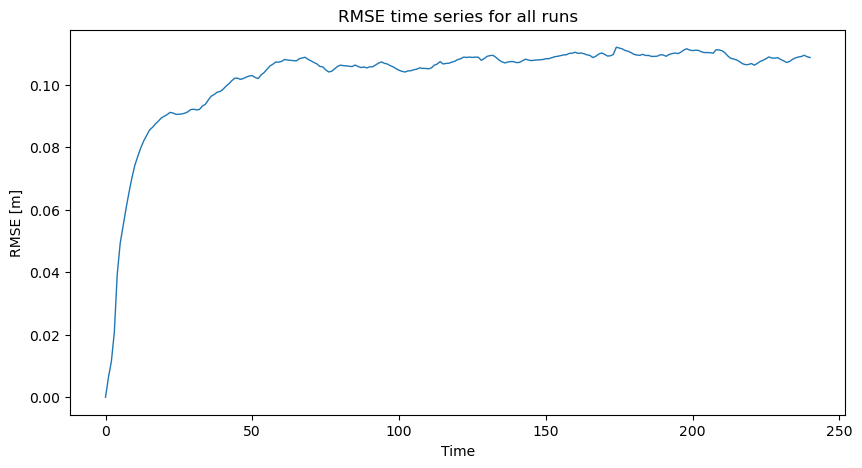

In [36]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(rmse_df.shape[1]), np.median(rmse_df, axis=0), label=f'RMSE', lw=1)
ax.set_title(f'RMSE time series for all runs')
ax.set_xlabel('Time')
ax.set_ylabel('RMSE [m]')
# ax.legend(fontsize='small')
plt.savefig(os.path.join(odir, f'{prefix}zeta_rmse_timeseries.png'), dpi=100)
print(f'RMSE time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmse_timeseries.png")}')
plt.show()

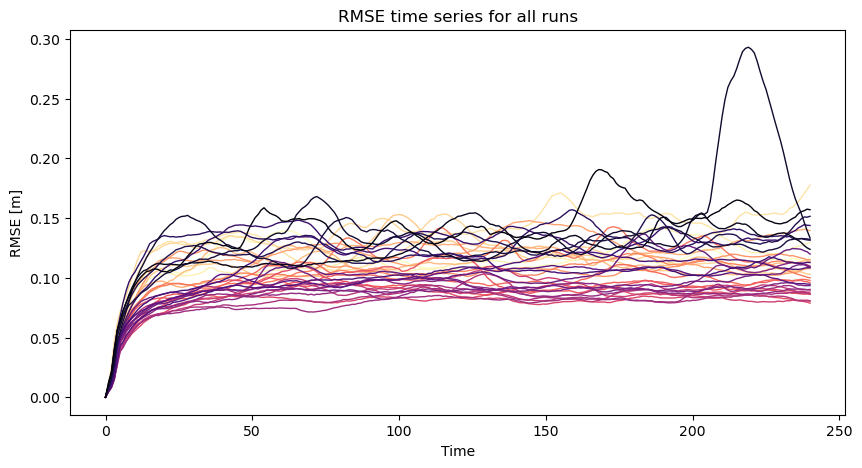

In [37]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(10, 5))
for ifile_idx in np.arange(rmse_df.shape[0]):
    ax.plot(np.arange(rmse_df.shape[1]), rmse_df.values[ifile_idx, :], lw=1, color=cm.magma_r(ifile_idx/rmse_df.shape[0]))
ax.set_title(f'RMSE time series for all runs')
ax.set_xlabel('Time')
ax.set_ylabel('RMSE [m]')
plt.show()

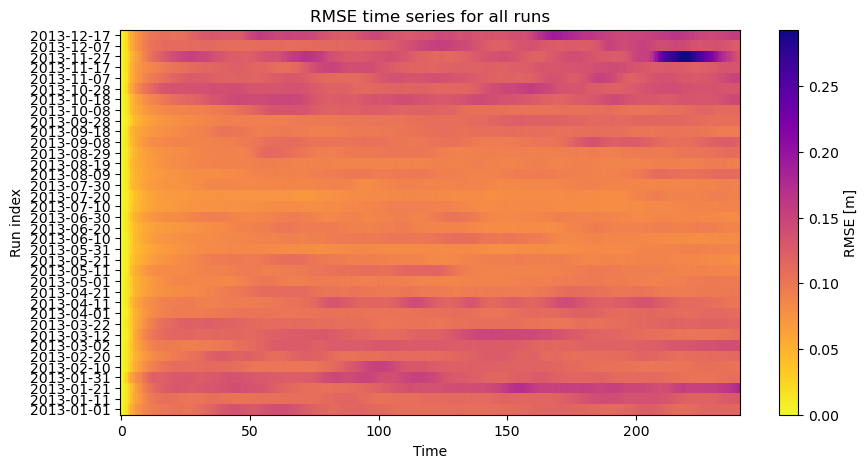

In [38]:
# Plot rmse_df as pcolormesh
fig, ax = plt.subplots(figsize=(10, 5))
pcm = ax.pcolormesh(rmse_df.columns.astype(int), rmse_df.index, rmse_df.values, cmap='plasma_r')
ax.set_title(f'RMSE time series for all runs')
ax.set_xlabel('Time')
ax.set_ylabel('Run index')
fig.colorbar(pcm, ax=ax, label='RMSE [m]')
plt.show()

In [ ]:
# Plot rmse_df as a ridged line plot
